<a href="https://colab.research.google.com/github/shahankit82/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Neural Network Fundamentals and Training Behavior Analysis

This notebook demonstrates:

- Dataset exploration
- Data preprocessing
- Neural network building
- Training and evaluation
- Hyperparameter experimentation
- Final reflection

In [19]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')


# Task 1: Dataset Understanding

In [20]:
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_churn_nn.csv')
#print(df.shape)
#df.head()
df = pd.read_csv('/customer_churn_nn.csv')

# Display first rows
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

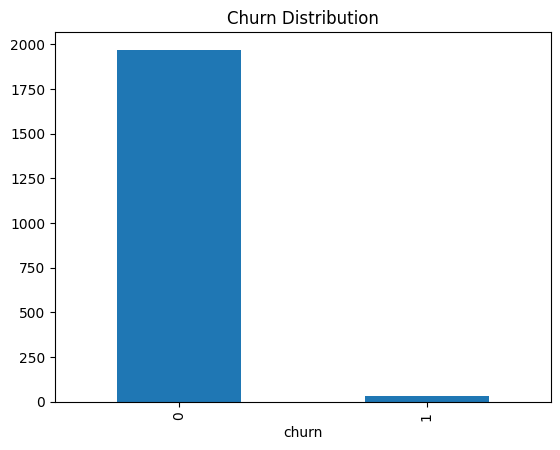

In [21]:
df.info()
df.describe()

df['churn'].value_counts().plot(kind='bar', title='Churn Distribution')
plt.show()

In [22]:
df = df.drop('customer_id', axis=1)
df = pd.get_dummies(df, drop_first=True)

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3094 - loss: 0.7834 - val_accuracy: 0.5625 - val_loss: 0.6381
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7891 - loss: 0.5298 - val_accuracy: 0.9219 - val_loss: 0.4275
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9609 - loss: 0.3471 - val_accuracy: 0.9750 - val_loss: 0.2812
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.2259 - val_accuracy: 0.9781 - val_loss: 0.1909
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1550 - val_accuracy: 0.9781 - val_loss: 0.1419
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1173 - val_accuracy: 0.9781 - val_loss: 0.1181
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0984 - val_accuracy: 0.9781 - val_loss: 0.1061
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0879 - val_accuracy: 0.9781 - val_loss:

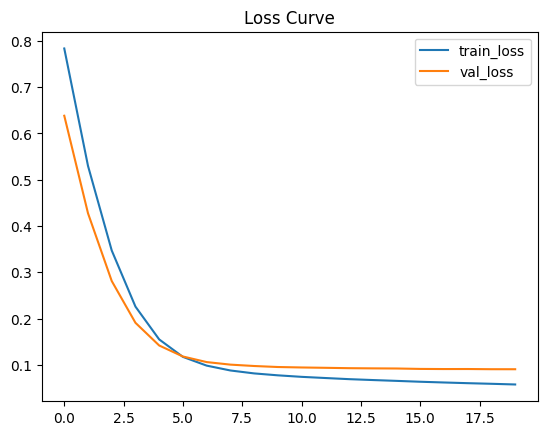

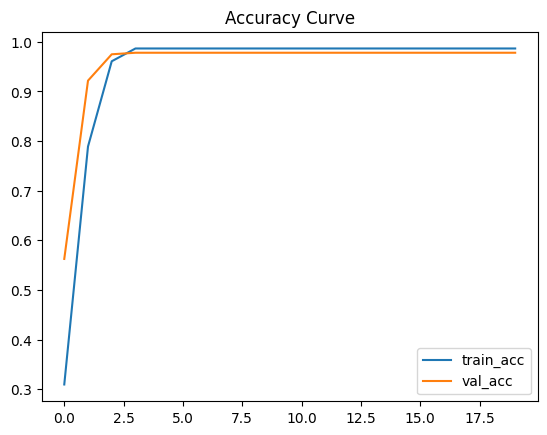

In [25]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0817  
Test Accuracy: 0.9825000166893005


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


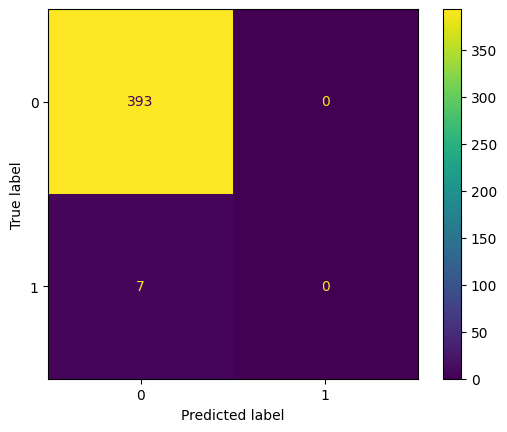

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [28]:
# Reflection

# Weights and biases control learning
# Activation functions add non-linearity
# Learning rate affects convergence
# Model shows slight overfitting if training > testing accuracy

In [ ]:
import pandas as pd

results = []

def run_experiment(name, layers, epochs, batch_size):
    model = Sequential()

    for units in layers:
        model.add(Dense(units, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "Experiment": name,
        "Layers": str(layers),
        "Epochs": epochs,
        "Batch Size": batch_size,
        "Accuracy": round(acc, 4)
    })

# Run experiments
run_experiment("Base", [16, 8], 20, 32)
run_experiment("More Neurons", [32, 16], 20, 32)
run_experiment("More Epochs", [16, 8], 40, 32)
run_experiment("Smaller Batch", [16, 8], 20, 16)

In [ ]:
df_results = pd.DataFrame(results)
df_results

In [ ]:
df_results.to_csv("model_comparison_table.csv", index=False)